In [27]:
import os
import sys
import glob
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', 150)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib as mpl
import seaborn as sns
from math import log
from scipy import stats
sns.set_theme()
try:
    from cellacdc import cca_functions
    from cellacdc import myutils
except FileNotFoundError:
    # Check if user has developer version --> add the Cell_ACDC/cellacdc
    # folder to path and import from thre
    sys.path.insert(0, '../cellacdc/')
    from cellacdc import cca_functions
    from cellacdc import myutils

# ***Import csv file generated at the end of script5 in dataprep*** 

In [28]:

overall_df = pd.read_csv(r"Y:\test_dfs_for_final_code\20231013_20231019_repscombined\final_processed_reps_combined_fluorescence_analysis_dataset.csv")


C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_8480\4063336030.py:2: DtypeWarning: Columns (31,32,53,321,323,324,325,329) have mixed types. Specify dtype option on import or set low_memory=False.
  overall_df = pd.read_csv(r"Y:\test_dfs_for_final_code\20231013_20231019_repscombined\final_processed_reps_combined_fluorescence_analysis_dataset.csv")


# ***Fig 6A: plotting Whi5-mCitrine and HTB2-mScarlet curves for one example cell cycle: 'YCY024_1_WTlabelled_Position_3_Cell_3_Gen_1_Rep_1'*** 

In [29]:
# l = display(overall_df[(overall_df['strain_sa'] == 'YCY024_1_WTlabelled') 
#                             & (overall_df['growthmedium_sa'] == "SCD")
#                             & (overall_df['cycle_saw_switch_sa'] == False)
#                             & (overall_df['complete_cycle_sa'] == True)
#                             & (overall_df['relationship_sa'] != "bud")].f_pos_cell_id_sa.unique())

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_8480\3723889817.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  a = sns.lineplot(x = "time_rel_to_bud_emergence_mins",
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_8480\3723889817.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), fontsize = 15)
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_8480\3723889817.py:44: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  a = sns.lineplot(x = "time_rel_to_bud_emergence_mins",
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


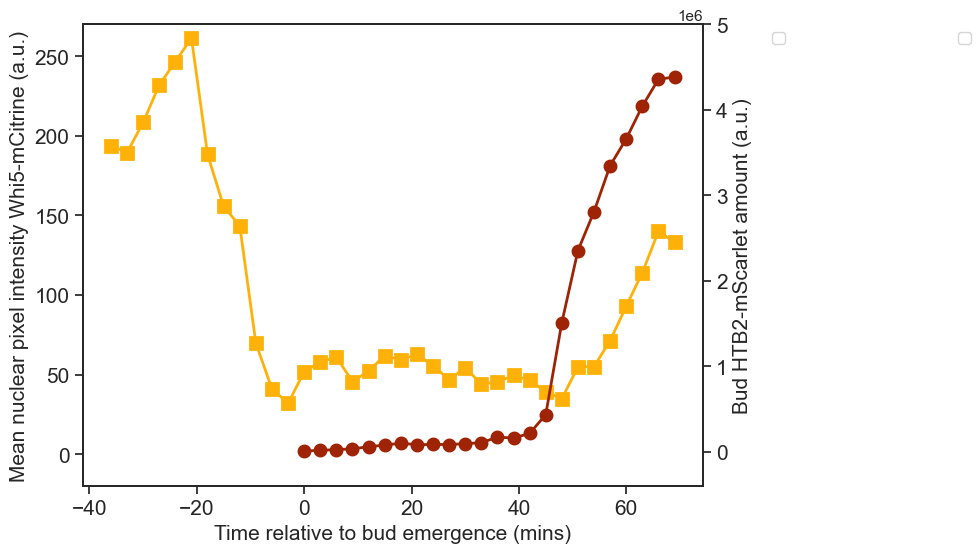

In [30]:
sns.set_theme()
sns.set_context("notebook", rc={"lines.linewidth": 1.5})
sns.set_style("ticks", {'grid.color': 'lightgrey'})

plot_df = overall_df[overall_df['f_pos_cell_id_sa'] == 'YCY024_1_WTlabelled_Position_3_Cell_3_Gen_1_Rep_1']


palette ={"preStart": "silver", "postStart": "mediumturquoise", "preMitotic": "mediumvioletred", "mitotic": "royalblue",
          "postMitotic": "#856798", "G1": "#88b378"}

a, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))
a = sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mCitrine_Yagya_combined_mother_bud_mean_pixel_intensity_nuc_cytosubtracted",
                marker = 's',
                markersize=8,
                data =plot_df,
                palette = palette,
                markeredgecolor = '#feb209',
                markeredgewidth= 2,
                linewidth=2,
                dashes = False,
                color = '#feb209',
                #s=100,
                #edgecolor = 'w',
                #height=8, 
                #aspect=1.5
                )

plt.legend(bbox_to_anchor=(1.4, 1),  loc='upper left')

sns.set_style("ticks", {'grid.color': 'darkgrey', 'grid.linestyle': '--'})
#create second x-axis on right side
ax2 = plt.twinx()
ax.set_ylim(-20,270)
ax.set_ylabel("Mean nuclear pixel intensity Whi5-mCitrine (a.u.)", fontsize = 15)

ax.set_xlabel("Time relative to bud emergence (mins)", fontsize = 15)
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 15)
ax2.set_ylabel("Bud HTB2-mScarlet amount (a.u.)", fontsize = 15)
ax2.set_ylim(-400000,5000000)

#plot histone cellular amount

a = sns.lineplot(x = "time_rel_to_bud_emergence_mins", 
                y = "mScarlet_Ph3_Yagya_amount_dataPrepBkgr_cell_rel",
                data =plot_df,
                marker = 'o',
                dashes = False,
                markersize=8,
                #marker="x",
                #s = 100,
                markeredgecolor = '#9f2305',
                markeredgewidth= 2,
                linewidth=2,
                color = '#9f2305',
                palette = palette,
                #height=8, 
                #aspect=1.5,
                ax=ax2)

plt.legend(bbox_to_anchor=(1.1, 1),  loc='upper left')

ax.tick_params(axis='y', which='major', labelsize=15)
ax2.tick_params(axis='y', which='major', labelsize=15)

#plt.grid()
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig6\panel1.svg", bbox_inches = 'tight')
plt.show()


# ***Fig 6C: dataprep***

In [32]:
ids_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    & (overall_df['complete_phase_sa'] == 1)
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ].f_pos_cell_id_sa.unique()
display(len(ids_first_S_daughters))
ids_that_could_not_be_manually_annotated = ["YCY030_2_Whi5del_labelled_Position_8_Cell_11_Gen_1_Rep_1",
"YCY030_2_Whi5del_labelled_Position_14_Cell_18_Gen_1_Rep_1",
"YCY037_1_Bck2del_labelled_Position_19_Cell_39_Gen_1_Rep_1",
"YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_22_Gen_1_Rep_1",
"YCY038_1_Whi5Bck2doubledel_labelled_Position_25_Cell_25_Gen_1_Rep_1",
"YCY024_1_WTlabelled_Position_9_Cell_15_Gen_1_Rep_2",
"YCY024_1_WTlabelled_Position_10_Cell_9_Gen_1_Rep_2",
"YCY030_2_Whi5del_labelled_Position_16_Cell_22_Gen_1_Rep_2",
"YCY038_1_Whi5Bck2doubledel_labelled_Position_26_Cell_51_Gen_1_Rep_2"]

108

In [33]:
# unique frame for each cell 
test_df = overall_df[(overall_df['f_pos_cell_id_sa'].isin(ids_first_S_daughters))] 
test_df = test_df[~test_df['f_pos_cell_id_sa'].isin(ids_that_could_not_be_manually_annotated)]
unique_f_pos_cell_id = []
for fposid in ((test_df['f_pos_cell_id_sa']).unique()):
    fposid_df = test_df[test_df['f_pos_cell_id_sa'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True)


plotting_df['preStart_G1_duration_mins'] = plotting_df['preStart_G1_duration_frames_manual']*3
plotting_df['postStart_G1_duration_mins'] = plotting_df['postStart_G1_duration_frames_manual']*3



# ***Fig 6C: plotting***

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_8480\2127791952.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax3.set_yticklabels(ax3.get_yticklabels(), fontsize = 15)


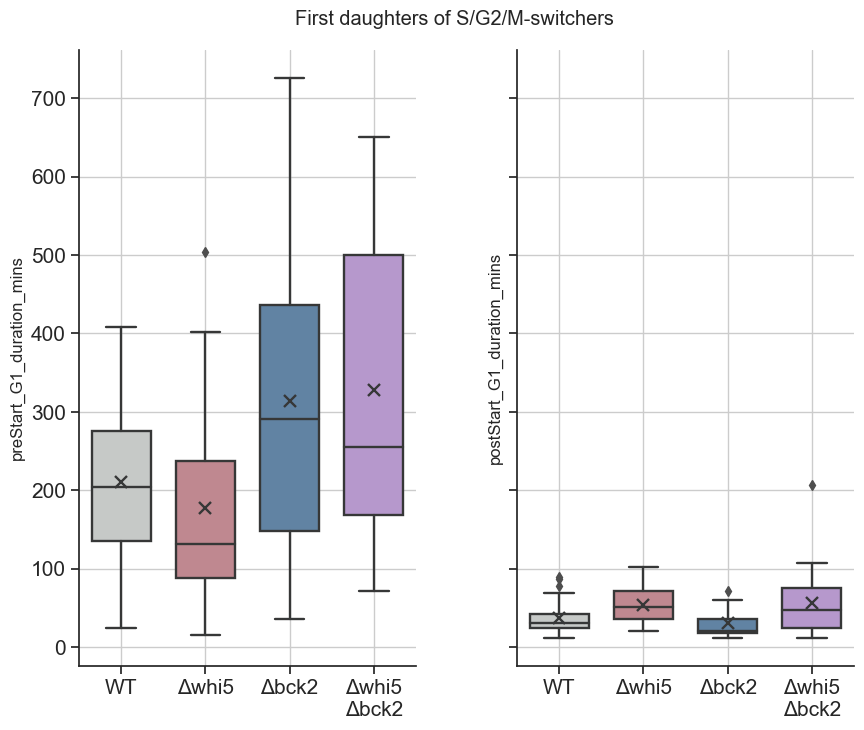

In [34]:
# plot it 

sns.set_theme()
sns.set_context("notebook", rc={"lines.linewidth": 1.7})
sns.set_style("ticks")
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}

d, (ax3, ax4) = plt.subplots(nrows=1, ncols=2, figsize=(10, 8), sharey = True)

lut = {"YCY024_1_WTlabelled":"#c5c9c7" , "YCY030_2_Whi5del_labelled": "#c87f89", 
       "YCY037_1_Bck2del_labelled": "#5684ae", "YCY038_1_Whi5Bck2doubledel_labelled":"#b790d4"}


d = sns.boxplot(data=plotting_df, 
                x="strain_sa", 
                y="preStart_G1_duration_mins", 
                order = ['YCY024_1_WTlabelled', 'YCY030_2_Whi5del_labelled','YCY037_1_Bck2del_labelled', 'YCY038_1_Whi5Bck2doubledel_labelled'], 
                showmeans = True,
                ax = ax3,
                width = 0.7,
                palette = lut,
                meanprops={"marker":"x",
                          "markerfacecolor":None,
                          "markeredgecolor":"#363737",
                          "markersize":"8",
                          "markeredgewidth": 1.7},
                **PROPS
               )
ax3.set_xticklabels(["WT",  "Δwhi5", "Δbck2", "Δwhi5\nΔbck2"], fontsize = 15)
ax3.set_yticklabels(ax3.get_yticklabels(), fontsize = 15)

#plt.setp(ax3.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
d.grid()

d = sns.boxplot(data=plotting_df, 
                x="strain_sa", 
                y="postStart_G1_duration_mins", 
                order = ['YCY024_1_WTlabelled', 'YCY030_2_Whi5del_labelled','YCY037_1_Bck2del_labelled', 'YCY038_1_Whi5Bck2doubledel_labelled'], 
                showmeans = True,
                ax = ax4,
                width = 0.7,
                palette = lut,
                meanprops={"marker":"x",
                          "markerfacecolor":None,
                          "markeredgecolor":"#363737",
                          "markersize":"8",
                          "markeredgewidth": 1.7},
                **PROPS
               )

ax4.set_xticklabels(["WT",  "Δwhi5", "Δbck2", "Δwhi5\nΔbck2"], fontsize = 15)
#plt.setp(ax4.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
d.grid()

ax3.set_xlabel("", fontsize = 15)
sns.despine(ax = ax3)
sns.despine(ax = ax4)
#ax1.set_xlabel("", fontsize = 15)
ax4.set_xlabel("", fontsize = 15)
plt.suptitle("First daughters of S/G2/M-switchers", y = 0.93)
plt.subplots_adjust(wspace = 0.3)

#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig6\panel2.svg", bbox_inches = 'tight')

In [35]:
print("complete G1 first daughters of sg2m switchers")
WT_df = plotting_df[(plotting_df["strain_sa"] == "YCY024_1_WTlabelled")]
whi5del_df =  plotting_df[(plotting_df["strain_sa"] == "YCY030_2_Whi5del_labelled")]
bck2del_df = plotting_df[(plotting_df["strain_sa"] == "YCY037_1_Bck2del_labelled")]
whi5bck2dd_df =  plotting_df[(plotting_df["strain_sa"] == "YCY038_1_Whi5Bck2doubledel_labelled")]


print("WT n", len(WT_df))
print("Bck2del n", len(bck2del_df))
print("whi5del n", len(whi5del_df))
print("whi5bck2dd n", len(whi5bck2dd_df))

#['YCY024_1_WTlabelled', 'YCY030_2_Whi5del_labelled','YCY037_1_Bck2del_labelled', 'YCY038_1_Whi5Bck2doubledel_labelled'],

complete G1 first daughters of sg2m switchers
WT n 38
Bck2del n 11
whi5del n 27
whi5bck2dd n 23


# ***Fig 6B: dataprep***

In [36]:
#pip install git+https://github.com/schlegelp/catheat@master

In [37]:
#%pip install catheat

import catheat
test_df.sort_values(by=['strain_sa', 'phase_length_sa'], inplace = True)
test_df = test_df[~test_df['f_pos_cell_id_sa'].isin(ids_that_could_not_be_manually_annotated)] 
test_df['time_rel_to_bud_emergence_mins'] =test_df['time_rel_to_bud_emergence_mins'].astype(int)
test_df['time_rel_to_bud_emergence_hrs'] =test_df['time_rel_to_bud_emergence_mins']/60
# display(test_df[["f_pos_cell_id_sa", "strain_sa", "total_G1_len_mins", 'time_rel_to_bud_emergence_mins','time_rel_to_bud_emergence_hrs' ]].head())
heatmap_df = test_df.pivot(index = ["f_pos_cell_id_sa", "strain_sa", "total_G1_len_mins"],
                                     values = "custom_G1_stage_manual", 
                                     columns = "time_rel_to_bud_emergence_hrs")
heatmap_df.sort_values(by=['strain_sa', 'total_G1_len_mins'], inplace = True)
# display(heatmap_df.head())
heatmap_df.reset_index(level = ("strain_sa", ), inplace = True)

,f_pos_cell_id_sa,strain_sa,total_G1_len_mins,time_rel_to_bud_emergence_mins,time_rel_to_bud_emergence_hrs
170274,YCY024_1_WTlabelled_Position_11_Cell_22_Gen_1_Rep_2,YCY024_1_WTlabelled,225.0,0,0.00
170275,YCY024_1_WTlabelled_Position_11_Cell_22_Gen_1_Rep_2,YCY024_1_WTlabelled,225.0,3,0.05
170276,YCY024_1_WTlabelled_Position_11_Cell_22_Gen_1_Rep_2,YCY024_1_WTlabelled,225.0,6,0.10
170277,YCY024_1_WTlabelled_Position_11_Cell_22_Gen_1_Rep_2,YCY024_1_WTlabelled,225.0,9,0.15
170278,YCY024_1_WTlabelled_Position_11_Cell_22_Gen_1_Rep_2,YCY024_1_WTlabelled,225.0,12,0.20


# ***Fig 6B: plotting***

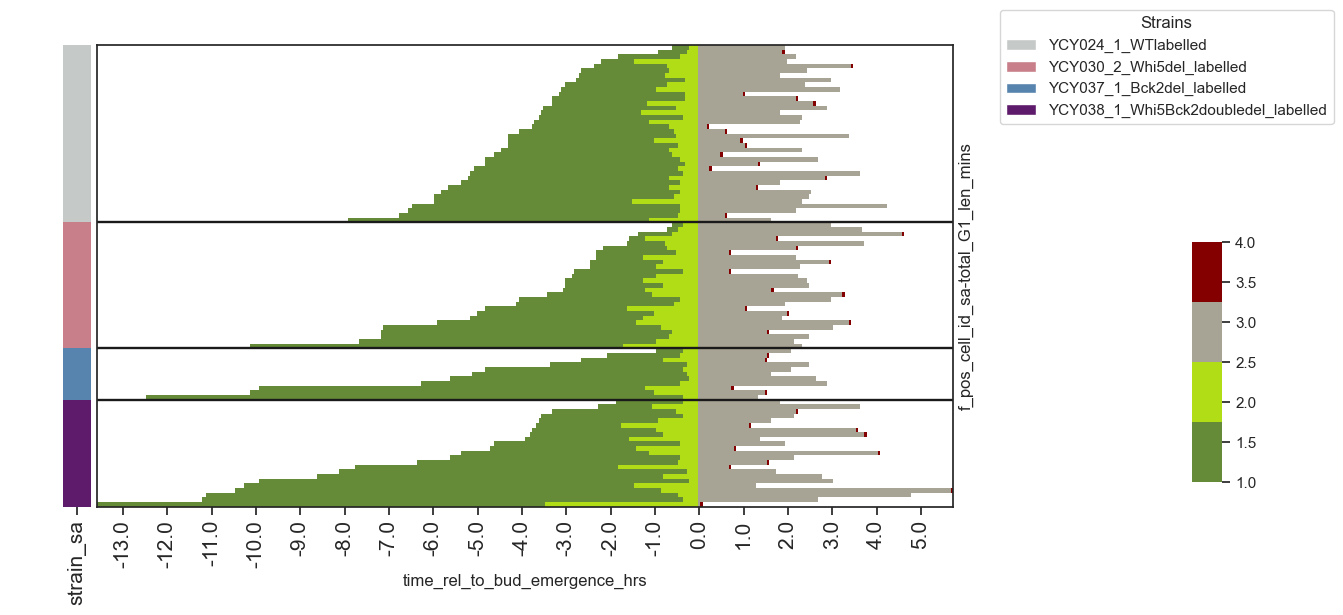

In [38]:
colors = ['#658b38', '#b0dd16',"#a8a495", "#840000"] 
lut = {"YCY024_1_WTlabelled":"#c5c9c7" , "YCY030_2_Whi5del_labelled": "#c87f89", "YCY037_1_Bck2del_labelled": "#5684ae", "YCY038_1_Whi5Bck2doubledel_labelled":"#5f1b6b"}

# numerise cell cycle categories
mymap = {'preStart':1, 'postStart':2, 'S':3, 'incomplete_S':4}
heatmap_df = heatmap_df.applymap(lambda s: mymap.get(s) if s in mymap else s)

row_colors = heatmap_df['strain_sa'].map(lut)

xtix = (np.arange(0,800, step = 20))
a = sns.clustermap(data=heatmap_df.drop(['strain_sa'], axis=1), 
                   figsize=(10,6),
                   row_colors=row_colors, 
                   row_cluster=False, 
                   col_cluster=False, 
                   dendrogram_ratio=0.05,
                   yticklabels = False,
                   xticklabels = True,
                   cmap = colors,
                   #linewidths = 0.0,
                   rasterized = True,
                   # linecolor = 'lightgray',
                   cbar_pos=(1.2, .2, .03, .4),
                  )
ax = a.ax_heatmap
#display(ax.get_xticklabels())

for _, spine in ax.spines.items():
    spine.set_visible(True)
    
ax.hlines([38,65,76], *ax.get_xlim(), color = 'k')
from matplotlib.patches import Patch

handles = [Patch(facecolor=lut[name]) for name in lut]
plt.legend(handles, lut, title='Strains',
           bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure, loc='upper left')



#only custom xtick labels to be printed
xticks_to_keep = [11, 31, 51, 71, 91, 111, 131, 151, 171, 191, 211, 231, 251, 271, 291, 311, 331, 351, 371]
[a.set_visible(False) for (i,a) in enumerate(ax.xaxis.get_ticklabels()) if i not in xticks_to_keep]
[a.set_visible(False) for (i,a) in enumerate(ax.xaxis.get_major_ticks()) if i not in xticks_to_keep]

a.tick_params(axis='x', which='major', labelsize=15)

plt.grid()
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig6\panel6.svg", bbox_inches = 'tight',dpi =1200)

# ***Fig S6: dataprep*** 

In [39]:
complete_phases_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    & (overall_df['complete_phase_sa'] == 1)
                                                    & (overall_df['cell_cycle_stage_sa'] == "G1")
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ] 
incomplete_phases_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    & (overall_df['complete_phase_sa'] == 0)
                                                    & (overall_df['does_cell_die_in_this_phase_sa'] == 0)
                                                    & (overall_df['cell_cycle_stage_sa'] == "G1")
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ]
dead_phases_first_S_daughters = overall_df[(overall_df['S_switch_cells_daughter_wave_sa'] == 1)
                                                    & ((overall_df['post_switch_gen_sa'] == 1)|
                                                    (overall_df['post_switch_gen_sa'] == "1.0"))
                                                    & (overall_df['complete_phase_sa'] == 0)
                                                    & (overall_df['does_cell_die_in_this_phase_sa'] == 1)
                                                    & (overall_df['cell_cycle_stage_sa'] == "G1")
                                                    & (overall_df['relationship_sa'] != "bud")
                                                    ]
# display(len(complete_phases_first_S_daughters.f_pos_cell_id_sa.unique()))
# display(len(incomplete_phases_first_S_daughters.f_pos_cell_id_sa.unique()))
# display(len(dead_phases_first_S_daughters.f_pos_cell_id_sa.unique()))

In [40]:
# getting only first G1 frames from all the cells
unique_f_pos_cell_id_1 = []
for fposid in ((complete_phases_first_S_daughters['f_pos_cell_id_sa']).unique()):
    fposid_df = complete_phases_first_S_daughters[complete_phases_first_S_daughters['f_pos_cell_id_sa'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    unique_f_pos_cell_id_1.append(fposid_df.iloc[:1])
plotting_df_complete = pd.concat(unique_f_pos_cell_id_1).reset_index(drop = True)
plotting_df_complete['G1_length_mins'] = plotting_df_complete['phase_length_sa']*3

unique_f_pos_cell_id_2 = []
for fposid in ((incomplete_phases_first_S_daughters['f_pos_cell_id_sa']).unique()):
    fposid_df = incomplete_phases_first_S_daughters[incomplete_phases_first_S_daughters['f_pos_cell_id_sa'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    unique_f_pos_cell_id_2.append(fposid_df.iloc[:1])
plotting_df_incomplete = pd.concat(unique_f_pos_cell_id_2).reset_index(drop = True)
plotting_df_incomplete['G1_length_mins'] = plotting_df_incomplete['phase_length_sa']*3

unique_f_pos_cell_id_3 = []
for fposid in ((dead_phases_first_S_daughters['f_pos_cell_id_sa']).unique()):
    fposid_df = dead_phases_first_S_daughters[dead_phases_first_S_daughters['f_pos_cell_id_sa'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    unique_f_pos_cell_id_3.append(fposid_df.iloc[:1])
plotting_df_dead = pd.concat(unique_f_pos_cell_id_3).reset_index(drop = True)
plotting_df_dead['G1_length_mins'] = plotting_df_dead['phase_length_sa']*3



# ***Fig S6: plotting*** 

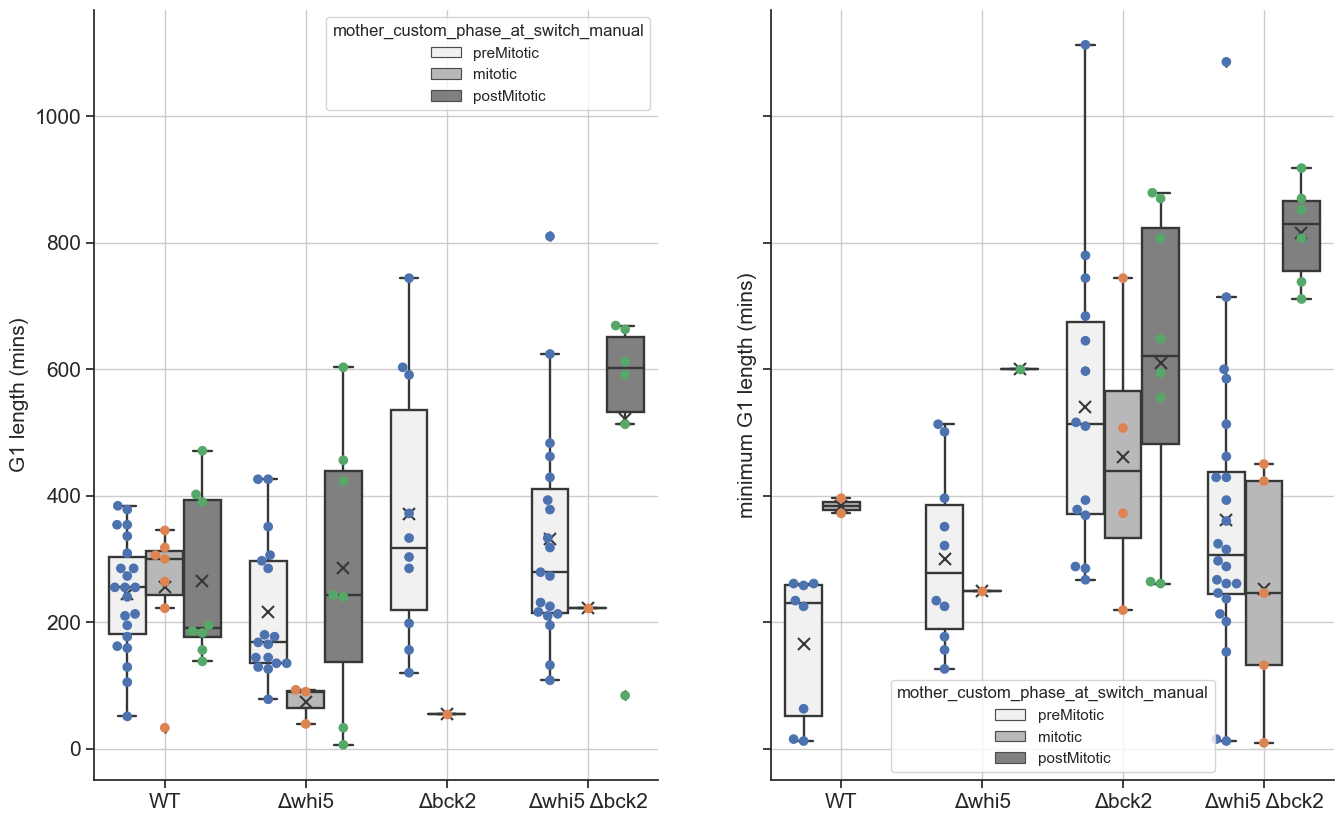

In [41]:
# plot it 
%matplotlib inline
sns.set_theme()
sns.set_context("notebook", rc={"lines.linewidth": 1.7})
sns.set_style("ticks")
plt.rcParams['ytick.labelsize'] = 15
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
lut = {"YCY024_1_WTlabelled":"#c5c9c7" , "YCY030_2_Whi5del_labelled": "#c87f89", 
       "YCY037_1_Bck2del_labelled": "#5684ae", "YCY038_1_Whi5Bck2doubledel_labelled":"#b790d4"}

d, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharex= False, sharey= True, figsize=(16, 10))
d = sns.boxplot(data=plotting_df_complete, 
                x="strain_sa", 
                y="G1_length_mins",
                showmeans = True,
                # kind = "box",
                #height = 8,
                #aspect = 1,
                hue = "mother_custom_phase_at_switch_manual",
                hue_order = ['preMitotic', 'mitotic', 'postMitotic'],
                meanprops={"marker":"x",
                          "markerfacecolor":None,
                          "markeredgecolor":"#363737",
                          "markersize":"8",
                          "markeredgewidth": 1.5},
                color = "grey",
                ax=ax1,
                **PROPS
               )
d.set_xticklabels(["WT",  "Δwhi5", "Δbck2", "Δwhi5 Δbck2"], fontsize = 15)

sns.despine(ax=ax1)
#plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
sns.swarmplot(data=plotting_df_complete, 
              x="strain_sa", 
              y="G1_length_mins",
              hue = "mother_custom_phase_at_switch_manual",
              hue_order = ['preMitotic', 'mitotic', 'postMitotic'],
              dodge = True,
              s =7,
              #color = "k",
              legend = False,
              ax=ax1
             )

plt.xlabel("", fontsize = 15)
plt.ylabel("G1 length (mins)", fontsize = 15)

d = sns.boxplot(data=plotting_df_incomplete, 
                x="strain_sa", 
                y="G1_length_mins",
                showmeans = True,
                # kind = "box",
                #height = 8,
                #aspect = 1,
                hue = "mother_custom_phase_at_switch_manual",
                hue_order = ['preMitotic', 'mitotic', 'postMitotic'],
                meanprops={"marker":"x",
                          "markerfacecolor":None,
                          "markeredgecolor":"#363737",
                          "markersize":"8",
                          "markeredgewidth": 1.5},
                color = "grey",
                ax=ax2,
                **PROPS
               )
d.set_xticklabels(["WT",  "Δwhi5", "Δbck2", "Δwhi5 Δbck2"], fontsize = 15)
#ax2.set_yticklabels(ax2.get_yticklabels(), fontsize = 15)
sns.despine(ax=ax2)
#plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
sns.swarmplot(data=plotting_df_incomplete, 
              x="strain_sa", 
              y="G1_length_mins",
              hue = "mother_custom_phase_at_switch_manual",
              hue_order = ['preMitotic', 'mitotic', 'postMitotic'],
              dodge = True,
              s =7,
              #color = "k",
              legend = False,
              ax=ax2
             )



ax1.set_xlabel("", fontsize = 15)
ax2.set_xlabel("", fontsize = 15)
#ax3.xlabel("", fontsize = 15)
ax1.set_ylabel("G1 length (mins)", fontsize = 15)
ax2.set_ylabel("minimum G1 length (mins)", fontsize = 15)
#ax3.ylabel("", fontsize = 15)
ax1.grid()
ax2.grid()

#ax3.grid()
# plt.suptitle("First daughters of S/G2/M switchers", fontsize = 15, y =0.93)
#d.suptitle('First daughters of S/G2/M switchers')
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig6\panel5_updated.svg", bbox_inches = 'tight')

# ***Fig6D and 6E: for only complete first daughters of S/G2/M switchers, plotting manual mother's combined_custom_S_stage_manual at switch*** 

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_8480\3252541795.py:71: UserWarning: FixedFormatter should only be used together with FixedLocator
  a.set_xticklabels(["WT",  "Δwhi5", "Δbck2", "Δwhi5 Δbck2"], fontsize = 15)


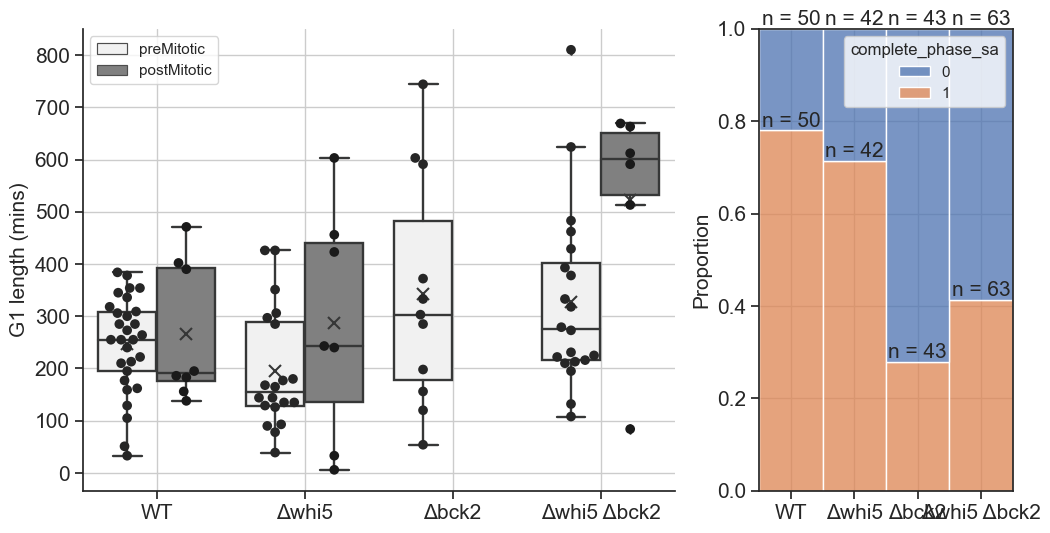

In [42]:
%matplotlib inline
sns.set_theme()
sns.set_context("notebook", rc={"lines.linewidth": 1.7})
sns.set_style("ticks")
plt.rcParams['ytick.labelsize'] = 15
PROPS = {
    'boxprops':{'edgecolor':"#363737"},
    'medianprops':{'color':"#363737"},
    'whiskerprops':{'color':"#363737"},
    'capprops':{'color':"#363737"}
}
lut = {"YCY024_1_WTlabelled":"#c5c9c7" , "YCY038_1_Whi5Bck2doubledel_labelled":"#b790d4"}

# plotting_df_complete_chosen_strains = plotting_df_complete[(plotting_df_complete['strain_sa'] == "YCY024_1_WTlabelled")| (plotting_df_complete['strain_sa'] == "YCY038_1_Whi5Bck2doubledel_labelled")]
# display(plotting_df_complete_chosen_strains.strain_sa.unique())

# combine preanaphasic (premitotic) and anaphasic (mitotic) into one category 
plotting_df_complete.loc[plotting_df_complete['mother_custom_phase_at_switch_manual'] == "mitotic", 'mother_custom_phase_at_switch_manual'] = "preMitotic"
plotting_df_incomplete.loc[plotting_df_incomplete['mother_custom_phase_at_switch_manual'] == "mitotic", 'mother_custom_phase_at_switch_manual'] = "preMitotic"

#plot
d, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharex= False, sharey= False, figsize=(12, 6), gridspec_kw={'width_ratios': [0.7,0.3]})
d = sns.boxplot(data=plotting_df_complete, 
                x="strain_sa", 
                y="G1_length_mins",
                showmeans = True,
                # kind = "box",
                #height = 8,
                #aspect = 1,
                hue = "mother_custom_phase_at_switch_manual",
                hue_order = ['preMitotic', 'postMitotic'],
                meanprops={"marker":"x",
                          "markerfacecolor":None,
                          "markeredgecolor":"#363737",
                          "markersize":"8",
                          "markeredgewidth": 1.5},
                color = "grey",
                ax=ax1,
                **PROPS
               )
d.set_xticklabels(["WT",  "Δwhi5", "Δbck2", "Δwhi5 Δbck2"], fontsize = 15)

sns.despine(ax=ax1)

sns.swarmplot(data=plotting_df_complete, 
              x="strain_sa", 
              y="G1_length_mins",
              hue = "mother_custom_phase_at_switch_manual",
              hue_order = ['preMitotic', 'postMitotic'],
              dodge = True,
              s =7,
              color = "k",
              legend = False,
              ax=ax1
             )

#combine complete and incomplete daughters plotting df
plotting_df_combined = pd.concat([plotting_df_complete, plotting_df_incomplete]).reset_index(drop = True)

# display(plotting_df_combined[['frame_i', 'Cell_ID', 'cell_saw_switch_sa', 'cell_saw_switch_as_bud_sa', 'S_switch_cells_daughter_wave_sa', 'Position_n', 'phase_length_sa', 'is_cell_dead_sa', 'does_cell_die_in_this_phase_sa', 'rep', 'relative_ID', 'cell_cycle_stage_sa',  'complete_phase_sa', 'cycle_saw_switch_sa', 'custom_S_stage', 'custom_postmitotic_stage', 'generation_num', 'relationship', 'complete_phase_sa', 'cycle_saw_switch_sa','mother_custom_phase_at_switch_manual']])
a = sns.histplot(data = plotting_df_combined,
                # kind = "hist",
                 hue = "complete_phase_sa",
                 x = "strain_sa", 
                 #hue = "mother_custom_phase_at_switch_manual",
                 multiple = "fill", 
                 discrete = True,
                 ax =ax2,
                 #col = "mother_custom_phase_at_switch_manual"
                )
a.set_xticklabels(["WT",  "Δwhi5", "Δbck2", "Δwhi5 Δbck2"], fontsize = 15)
#https://stackoverflow.com/questions/55104819/display-count-on-top-of-seaborn-barplot
for container in ax2.containers:
    ax2.bar_label(container, labels = ["n = 50", "n = 42", "n = 43", "n = 63"], fontsize = 15)
# plt.xlabel("", fontsize = 15)
# plt.ylabel("G1 length (mins)", fontsize = 15)


ax1.legend(loc = 'upper left')
ax1.set_xlabel("", fontsize = 15)
ax2.set_xlabel("", fontsize = 15)
# #ax3.xlabel("", fontsize = 15)
ax1.set_ylabel("G1 length (mins)", fontsize = 15)
ax2.set_ylabel("Proportion", fontsize = 15)
# #ax3.ylabel("", fontsize = 15)
ax1.grid()
ax2.grid()

# #ax3.grid()
# # plt.suptitle("First daughters of S/G2/M switchers", fontsize = 15, y =0.93)
# #d.suptitle('First daughters of S/G2/M switchers')
#plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig6\newpanels_DandE_01102024.svg", bbox_inches = 'tight')

In [43]:
#colors and axis labels were edited in inkscape


#by changing multiple to 'dodge' in stacked histplot above and printing container labels, i got the following cell numbers for complete + incomplete cells
# WT 50 (39 complete + 11 incomplete)
# Whi5del 42 (30 complete + 12 incomplete)
# Bck2del 43 (12 complete + 31 incomplete)
# whi5bck2dd 63 (26 complete + 37 incomplete)

